# Corrective RAG

Corrective RAG (CRAG) is an advanced technique within Retrieval-Augmented Generation (RAG) that focuses on improving the **accuracy and relevance** of generated responses by incorporating mechanisms for **self-reflection and self-grading of retrieved documents**.

It evaluates the quality of retrieved documents and applies **corrective actions** when necessary, such as refining the query or replacing incorrect retrievals.

## How Corrective RAG Works with LangGraph

1. **Receive the Question:** The workflow receives the user's question.
2. **Retrieve Documents:** The `Retrieve` node retrieves relevant documents from the knowledge base.
3. **Grade Documents:** The `Grade` node evaluates the relevance of the retrieved documents.
4. **Check Document Relevance:** The workflow determines whether any retrieved document is irrelevant.
5. **Use Retrieved Documents:** If the documents are relevant, the workflow proceeds to generate the final answer.
6. **Rewrite the Query:** If any document is irrelevant, the `Re-write query` node reformulates the user's question.
7. **Perform Web Search:** The rewritten query is sent to the `Web Search` node to obtain additional information.
8. **Generate the Answer:** The retrieved information is provided to the generation node to produce the final answer.

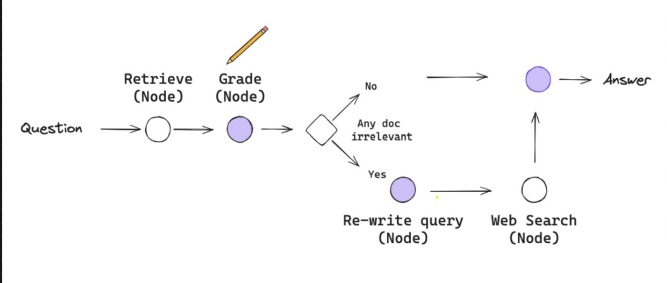

## Benefits of Corrective RAG

- **Improved Accuracy:** Evaluates retrieved documents before using them to generate an answer.
- **Better Document Relevance:** Identifies irrelevant documents through document grading.
- **Query Refinement:** Rewrites the query when the initial retrieval is not useful.
- **Corrective Retrieval:** Uses web search when the retrieved documents are insufficient.
- **Self-Reflection:** Evaluates the quality of retrieved information before generating the final response.
- **More Reliable Answers:** Helps improve the quality of generated responses by combining document grading, query rewriting, and additional search.
- **Flexible Workflow:** Allows retrieval, grading, rewriting, web search, and generation to work together through conditional routing.

## Setting Up the Environment

In [22]:
### Loading Environment Variables
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN')
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

## Building the Vector Store

In [23]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

### from langchain_cohere import CohereEmbeddings

### Creating Hugging Face Embeddings
embd = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

### Loading Documents
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

### Splitting Documents into Chunks
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

### Creating the FAISS Vector Store
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=embd
)

### Creating the Retriever
retriever=vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 916.68it/s]


## Building the Retrieval Grader

In [24]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

### Defining the Grading Model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with function call
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

### Creating the Grading Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

### Grading the Retrieved Documents
retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


## Building the RAG Generator

In [25]:
from langchain_core.output_parsers import StrOutputParser

### Creating the RAG Prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an assistant for question-answering tasks. Use the following retrieved context to answer the question. If you do not know the answer, say that you do not know. Keep the answer concise."),
    ("human", "Question: {question}\n\nContext: {context}"),
])

# LLM
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

### Generating the Answer
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

In LLM-powered autonomous agents, memory is a key component that allows the agent to retain and recall information. It is typically divided into two types:

*   **Short-term memory:** Utilizes in-context learning (prompt engineering) to handle immediate tasks and recent interactions.
*   **Long-term memory:** Enables the agent to retain and recall information over extended periods, often by leveraging an external vector store and fast retrieval mechanisms (such as Maximum Inner Product Search).

In systems like Generative Agents, long-term memory is implemented as a "memory stream" (an external database recording experiences in natural language), which is retrieved based on relevance, recency, and importance to inform the agent's behavior and planning.


## Building the Question Rewriter

In [26]:
# LLM
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)

### Creating the Rewriting Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

### Rewriting the User Query
question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'The phrase "agent memory" is too broad and ambiguous for an effective web search. It could refer to:\n1.  **AI/LLM Context:** How large language models or autonomous agents store and retrieve information (e.g., vector databases, RAG, long-term vs. short-term memory).\n2.  **Computer Science/OS:** Memory management for software agents or processes.\n3.  **Cognitive Science:** How human or animal agents remember.\n\nGiven the current tech landscape, the most likely intent is related to **AI agents and LLMs**. To optimize for web search, we should clarify the context (AI/LLM) and the specific aspect (mechanisms, architectures, or best practices).\n\nHere are a few improved versions depending on the specific intent:\n\n**Option 1 (General AI/LLM Focus - Recommended):**\n> "How do AI agents implement long-term and short-term memory in LLM applications?"\n\n**Option 2 (Technical/Architecture Focus):**\n> "Architectures for agent memory in LLMs: vector databases, RAG, and state management"\n

## Setting Up Web Search

In [27]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

## Defining the Graph State

In [28]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document

### Creating the Graph State
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

## Creating the Corrective RAG Nodes

### Creating the Retrieval Node

In [29]:
def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

### Creating the Generate Node

In [30]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

### Creating the Document Grading Node

In [31]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}

### Creating the Query Transformation Node

In [32]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

### Creating the Web Search Node

In [33]:
def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

### Creating the Generation Edge

In [34]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

## Building the Corrective RAG Workflow

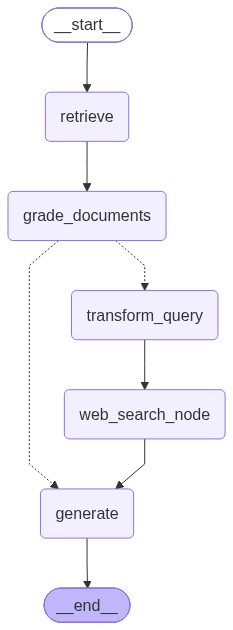

In [35]:
from langgraph.graph import END, StateGraph, START

### Creating the State Graph
workflow = StateGraph(GraphState)

### Adding the Nodes to the Graph
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

### Adding the Edges Between Nodes
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

### Compiling the Graph
app = workflow.compile()

### Visualizing the Workflow
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## Running the Corrective RAG Application

In [38]:
app.invoke({"question":"What is prompt engineering?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': 'The original question, "What is prompt engineering?", is a standard definitional query. While it will yield results, it often returns generic dictionary-style definitions or introductory blog posts. To optimize for web search, it is beneficial to specify the context (e.g., Large Language Models/AI) and the desired depth (e.g., techniques, best practices, or practical application). This helps the search engine prioritize high-quality, actionable, and up-to-date technical resources over basic overviews.\n\nHere are a few improved versions depending on the specific intent:\n\n**Option 1 (Comprehensive & Technical - Recommended):**\n> "What are the core principles and best practices of prompt engineering for Large Language Models (LLMs)?"\n\n**Option 2 (Practical/Action-Oriented):**\n> "How to write effective prompts for AI: key techniques and examples of prompt engineering"\n\n**Option 3 (Comparative/Advanced):**\n> "Advanced prompt engineering techniques vs. basic prompting

In [37]:
app.invoke({"question":"Who is Tony Stark?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': 'The original question "Who is Tony Stark?" is ambiguous because the name refers to two distinct entities: the fictional character from Marvel Comics/MCU and potentially real-world individuals with the same name. To optimize for web search, it is best to assume the user is asking about the most prominent figure, the fictional superhero, while adding context to filter out unrelated results.\n\n**Improved Question:**\n**"Tony Stark Marvel character biography and origin"**\n\n**Alternative (if broader context is needed):**\n**"Who is Tony Stark in the Marvel Cinematic Universe?"**',
 'generation': 'Tony Stark, also known as Iron Man, is a fictional character in the Marvel Cinematic Universe (MCU) and Marvel Comics. In the MCU, he is portrayed by Robert Downey Jr. and is depicted as a genius inventor, industrialist, and CEO of Stark Industries who creates powered armor to defend Earth. He is a founding member and leader of the Avengers.',
 'web_search': 'Yes',
 'documents': [D